In [72]:
import pandas as pd 

In [73]:
import os
os.listdir("../data")


['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [74]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [75]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [76]:
df.shape

(7043, 21)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [78]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [79]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [80]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Dataset Overview

- Number of rows: 7043
- Number of columns: 21
- Target variable: Churn

This dataset contains customer information such as tenure, services, charges, and churn status.

In [81]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Target Variable Analysis

The dataset is imbalanced:
- 5174 customers did not churn
- 1869 customers churned

This imbalance may affect model performance and needs to be handled later.

In [82]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [83]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [84]:
df["TotalCharges"]

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [85]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [86]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [87]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [88]:
df.drop("customerID", axis=1, inplace=True)

In [89]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [90]:
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in yes_no_cols:
    df[col] = df[col].map({"yes":1, "No":0})

In [91]:
df = pd.get_dummies(df, drop_first=True)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                3641 non-null   float64
 2   Dependents                             4933 non-null   float64
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           682 non-null    float64
 5   PaperlessBilling                       2872 non-null   float64
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   gender_Male                            7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [93]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

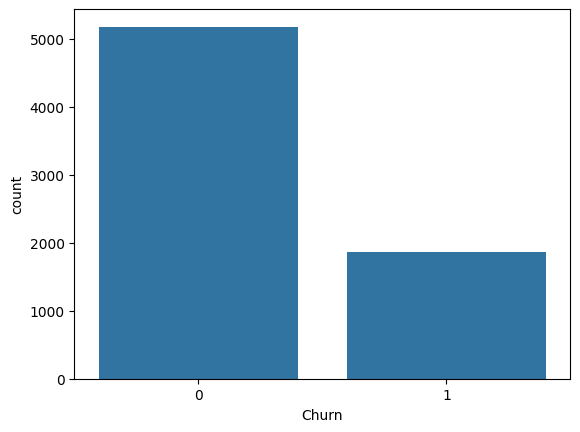

In [95]:
sns.countplot(x="Churn", data = df)
plt.show()

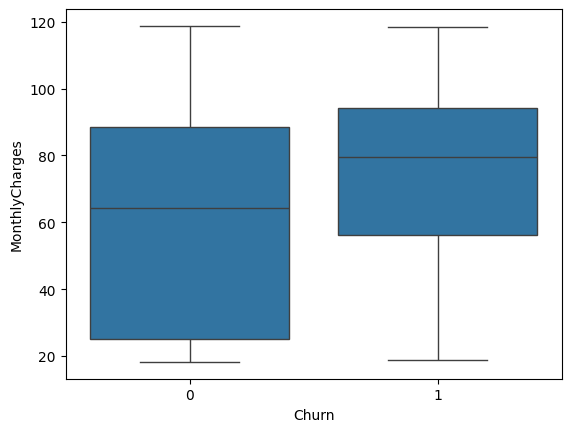

In [96]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

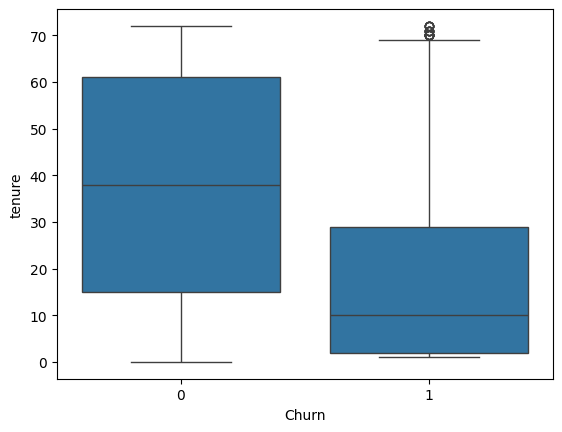

In [97]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

In [98]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [99]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [100]:
x.shape, y.shape

((7043, 30), (7043,))

Train-Test Split

In [101]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
x, y, test_size=0.2, random_state=42
)

In [102]:
x_train.shape, y_train.shape

((5634, 30), (5634,))

In [103]:
from sklearn.linear_model import LogisticRegression

In [104]:
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
df.isnull().sum()

SeniorCitizen                               0
Partner                                  3402
Dependents                               2110
tenure                                      0
PhoneService                             6361
PaperlessBilling                         4171
MonthlyCharges                              0
TotalCharges                                0
Churn                                       0
gender_Male                                 0
MultipleLines_No phone service              0
MultipleLines_Yes                           0
InternetService_Fiber optic                 0
InternetService_No                          0
OnlineSecurity_No internet service          0
OnlineSecurity_Yes                          0
OnlineBackup_No internet service            0
OnlineBackup_Yes                            0
DeviceProtection_No internet service        0
DeviceProtection_Yes                        0
TechSupport_No internet service             0
TechSupport_Yes                   

In [ ]:
df = df.fillna(0)

In [ ]:
x,y

(      SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
 0                 0      NaN         0.0       1           0.0   
 1                 0      0.0         0.0      34           NaN   
 2                 0      0.0         0.0       2           NaN   
 3                 0      0.0         0.0      45           0.0   
 4                 0      0.0         0.0       2           NaN   
 ...             ...      ...         ...     ...           ...   
 7038              0      NaN         NaN      24           NaN   
 7039              0      NaN         NaN      72           NaN   
 7040              0      NaN         NaN      11           0.0   
 7041              1      NaN         0.0       4           NaN   
 7042              0      0.0         0.0      66           NaN   
 
       PaperlessBilling  MonthlyCharges  TotalCharges  gender_Male  \
 0                  NaN           29.85         29.85        False   
 1                  0.0           56.95       1889.50 

In [ ]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
model.fit(x_train,y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
x.isnull().sum().sort_values(ascending=False).head(10)

SeniorCitizen                     0
Partner                           0
Dependents                        0
tenure                            0
PhoneService                      0
PaperlessBilling                  0
MonthlyCharges                    0
TotalCharges                      0
gender_Male                       0
MultipleLines_No phone service    0
dtype: int64

In [ ]:
x.isnull().sum().sum()


np.int64(0)

In [ ]:
x = x.fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
model.fit(x_train,y_train)

c:\Users\Balraj\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8119233498935415


In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[924, 112],
       [153, 220]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1036
           1       0.66      0.59      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7991483321504613


In [106]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=x.columns)
importance.sort_values(ascending=False).head(10)


TotalCharges                      0.223113
MonthlyCharges                    0.188831
tenure                            0.182198
InternetService_Fiber optic       0.043093
PaymentMethod_Electronic check    0.038955
Contract_Two year                 0.029424
gender_Male                       0.029333
OnlineSecurity_Yes                0.026341
TechSupport_Yes                   0.024005
Contract_One year                 0.023788
dtype: float64

In [107]:
df["Churn_Prediction"] = rf_model.predict(x)

In [111]:
df.to_csv("../data/final_churn_data.csv", index=False)